### CELL 1 - Import

In [22]:
# ============================================================
# CELL 1 — Import & Setup
# ============================================================
import sys, os
sys.path.append(os.path.abspath("../"))

from src.graph.graph_analysis import (
    compute_all_centrality, build_centrality_df,
    save_centrality, print_graph_info, get_top_districts
)
# Import build_graph từ module của thành viên A
from src.graph.graph_builder import build_graph

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
os.makedirs("../outputs/charts", exist_ok=True)

### CELL 2 -build graph

In [23]:
# ============================================================
# CELL 2 — Build Graph & Kiểm tra cơ bản
# ============================================================
G = build_graph(
    "../data/processed/adjacency_matrix.csv",
    "../data/raw/traffic_index.csv"
)
print_graph_info(G)

===== GRAPH INFO =====
Nodes  : 22
Edges  : 54
Connected: True
Degree — max: 7, min: 1, avg: 4.91
Weight — max: 1.000, min: 0.076, avg: 0.385


### CELL 3 — Compute centrality

In [24]:
# ============================================================
# CELL 3 — Tính toàn bộ Centrality
# ============================================================
centrality = compute_all_centrality(G)
df = build_centrality_df(G, centrality)
save_centrality(df, "../data/processed/centrality_scores.csv")
df.head()

Saved: ../data/processed/centrality_scores.csv


,district,degree,betweenness,closeness,pagerank
0,Quận1,0.333333,0.223810,0.157915,0.075945
1,Quận4,0.238095,0.214286,0.148315,0.050526
2,Quận7,0.238095,0.161905,0.122838,0.039005
3,PhúNhuận,0.238095,0.152381,0.158596,0.054259
4,Quận12,0.333333,0.142857,0.118834,0.046660


### CELL 4 - Ranking

In [25]:
# ============================================================
# CELL 4 — Bảng ranking đầy đủ 22 quận (yêu cầu chính)
# ============================================================
df["rank_degree"]      = df["degree"].rank(ascending=False).astype(int)
df["rank_betweenness"] = df["betweenness"].rank(ascending=False).astype(int)
df["rank_closeness"]   = df["closeness"].rank(ascending=False).astype(int)
df["rank_pagerank"]    = df["pagerank"].rank(ascending=False).astype(int)

ranking_table = df[[
    "district",
    "rank_betweenness", "rank_degree",
    "rank_closeness",   "rank_pagerank"
]].sort_values("rank_betweenness")

print(f"Tổng số quận/huyện trong đồ thị: {len(df)}")
ranking_table

Tổng số quận/huyện trong đồ thị: 22


,district,rank_betweenness,rank_degree,rank_closeness,rank_pagerank
0,Quận1,1,2,4,1
1,Quận4,2,12,8,9
2,Quận7,3,12,14,15
3,PhúNhuận,4,12,2,8
4,Quận12,5,2,16,12
5,TânBình,6,2,6,5
6,Quận5,7,2,5,2
7,GòVấp,8,18,11,14
8,HócMôn,9,18,19,18
9,NhàBè,9,20,20,19


### CELL 5 - Plot function

In [26]:
# ============================================================
# CELL 5 — Hàm vẽ bar chart chuẩn
# ============================================================
COLORS = {
    "degree":      "#4C72B0",
    "betweenness": "#DD8452",
    "closeness":   "#55A868",
    "pagerank":    "#C44E52",
}

def plot_top(df, column, title, filename, top_n=10):
    top = df.sort_values(column, ascending=False).head(top_n).copy()

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(top["district"], top[column],
                   color=COLORS.get(column, "#4C72B0"), alpha=0.85)

    # Thêm value label trên từng bar
    for bar, val in zip(bars, top[column]):
        ax.text(bar.get_width() + bar.get_width() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", ha="left", fontsize=9)

    ax.invert_yaxis()
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Centrality Score", fontsize=10)
    ax.set_ylabel("Quận/Huyện", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

    plt.tight_layout()
    out_path = f"../outputs/charts/{filename}"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

### CELL 6 - Plot All

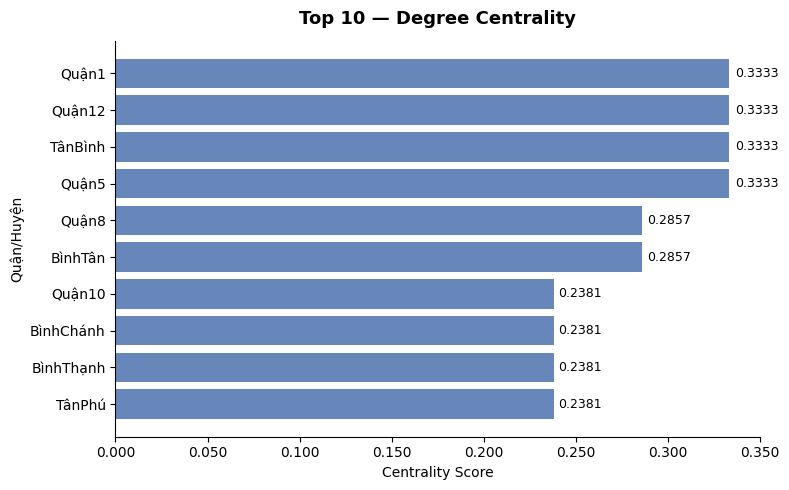

Saved: ../outputs/charts/degree.png


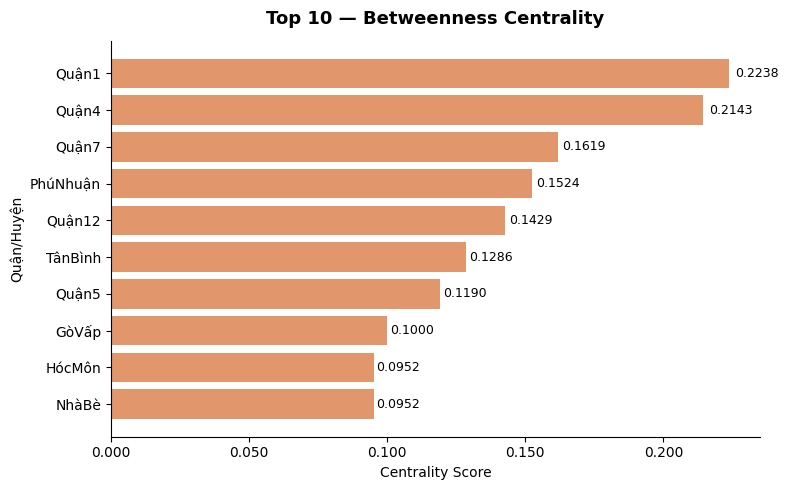

Saved: ../outputs/charts/betweenness.png


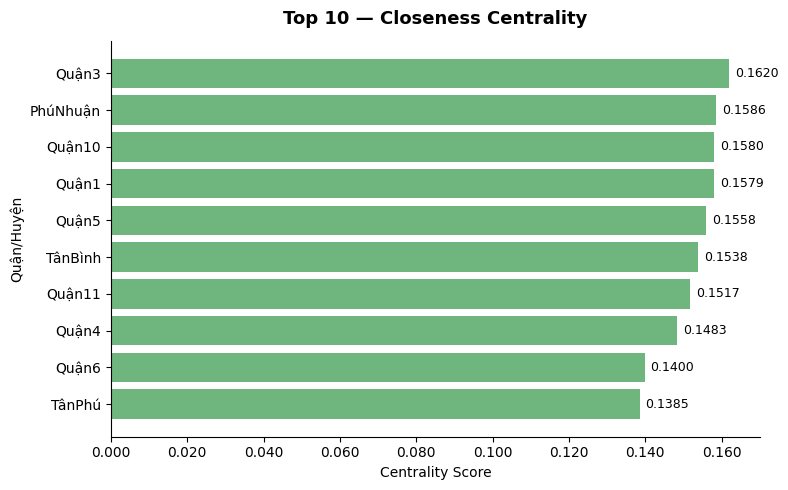

Saved: ../outputs/charts/closeness.png


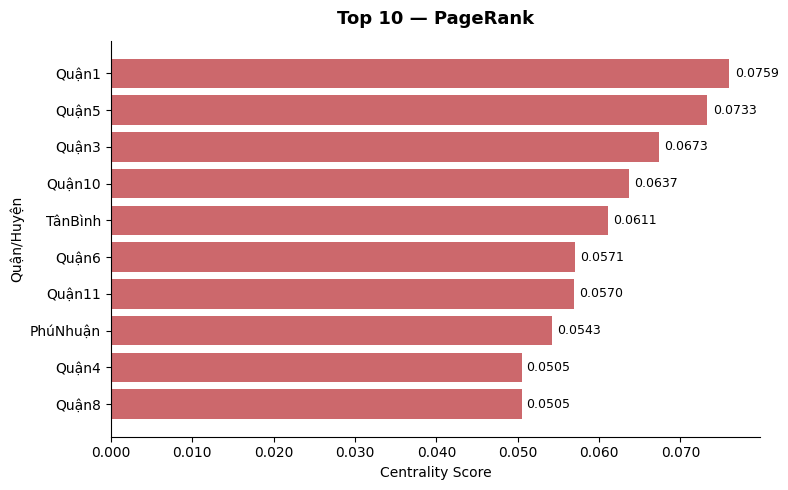

Saved: ../outputs/charts/pagerank.png


In [27]:
# ============================================================
# CELL 6 — Vẽ 4 biểu đồ
# ============================================================
plot_top(df, "degree",      "Top 10 — Degree Centrality",      "degree.png")
plot_top(df, "betweenness", "Top 10 — Betweenness Centrality",  "betweenness.png")
plot_top(df, "closeness",   "Top 10 — Closeness Centrality",    "closeness.png")
plot_top(df, "pagerank",    "Top 10 — PageRank",                "pagerank.png")

### CELL 7 - Compare với cạnh

In [ ]:
# ============================================================
# CELL 7 — Phân tích tổng hợp: quận nào xuất hiện nhiều ở top
# ============================================================
TOP_N = 5
top_sets = {
    metric: set(get_top_districts(centrality[metric], n=TOP_N))
    for metric in ["degree", "betweenness", "closeness", "pagerank"]
}

# Đếm số lần xuất hiện trong top 5 của từng metric
all_districts = list(G.nodes())
appear_count = {}
for d in all_districts:
    count = sum(1 for metric in top_sets if any(x[0] == d for x in top_sets[metric]))
    if count > 0:
        appear_count[d] = count

appear_df = pd.DataFrame(appear_count.items(),
                         columns=["district", "top5_count"]
                         ).sort_values("top5_count", ascending=False)

print("=== Quận xuất hiện nhiều nhất trong top 5 của các chỉ số ===")
print(appear_df)


key_districts = appear_df[appear_df["top5_count"] >= 3]["district"].tolist()
print(f"\n→ Quận trung tâm lan truyền quan trọng nhất: {', '.join(key_districts)}")
print("  Đây là các quận cần ưu tiên giám sát và phân bổ nguồn lực y tế.")

=== Quận xuất hiện nhiều nhất trong top 5 của các chỉ số ===
   district  top5_count
2     Quận1           4
7     Quận5           3
1  PhúNhuận           2
3    Quận10           2
4    Quận12           2
5     Quận3           2
9   TânBình           2
0   BìnhTân           1
6     Quận4           1
8     Quận7           1

→ Quận trung tâm lan truyền quan trọng nhất: Quận1, Quận5
  Đây là các quận cần ưu tiên giám sát và phân bổ nguồn lực y tế.


### CELL 8 — So sánh Betweenness vs Ca bệnh thực tế

In [29]:
# ============================================================
# CELL 8 — Fix tên quận + So sánh Betweenness vs Ca bệnh
# ============================================================
import unicodedata
df = df.copy()  # ← FIX duy nhất cần thêm
def normalize_district_name(name: str) -> str:
    """
    Chuẩn hóa tên quận về dạng so sánh:
    - Lowercase
    - Bỏ dấu cách thừa
    - Giữ nguyên dấu tiếng Việt (không strip accent)
    Ví dụ: 'Quận 1' → 'quận 1', 'quận1' → 'quận 1' (KHÔNG làm vậy)
    → Chỉ lower + strip để tránh mất thông tin
    """
    return str(name).strip().lower()

# Áp dụng normalize cho cả hai phía
df["district_norm"] = df["district"].apply(normalize_district_name)

cases_df = pd.read_csv(
    "../data/raw/dengue_cases_by_district_2022_2024.csv",
    encoding="utf-8-sig"
)
cases_df["district_norm"] = cases_df["district_name"].apply(normalize_district_name)

# Xem thực tế hai bên trông như thế nào
print("=== Tên quận trong adjacency_matrix (graph) ===")
print(sorted(df["district_norm"].tolist()))

print("\n=== Tên quận trong CSV ca bệnh ===")
print(sorted(cases_df["district_norm"].unique().tolist()))

=== Tên quận trong adjacency_matrix (graph) ===
['bìnhchánh', 'bìnhthạnh', 'bìnhtân', 'cầngiờ', 'củchi', 'gòvấp', 'hócmôn', 'nhàbè', 'phúnhuận', 'quận1', 'quận10', 'quận11', 'quận12', 'quận3', 'quận4', 'quận5', 'quận6', 'quận7', 'quận8', 'thủ đức', 'tânbình', 'tânphú']

=== Tên quận trong CSV ca bệnh ===
['bình chánh', 'bình thạnh', 'bình tân', 'cần giờ', 'củ chi', 'gò vấp', 'hóc môn', 'nhà bè', 'phú nhuận', 'quận 1', 'quận 10', 'quận 11', 'quận 12', 'quận 3', 'quận 4', 'quận 5', 'quận 6', 'quận 7', 'quận 8', 'thủ đức', 'tân bình', 'tân phú']


In [30]:
# ============================================================
# CELL 8b — Mapping table chuẩn hóa tên quận
# ============================================================

# Key = tên trong adjacency_matrix (graph node)
# Value = tên trong district_name của CSV
DISTRICT_NAME_MAP = {
    "quận1":      "quận 1",
    "quận3":      "quận 3",
    "quận4":      "quận 4",
    "quận5":      "quận 5",
    "quận6":      "quận 6",
    "quận7":      "quận 7",
    "quận8":      "quận 8",
    "quận10":     "quận 10",
    "quận11":     "quận 11",
    "quận12":     "quận 12",
    "bìnhthạnh":  "bình thạnh",
    "bìnhtân":    "bình tân",
    "bìnhchánh":  "bình chánh",
    "gòvấp":      "gò vấp",
    "phúnhuận":   "phú nhuận",
    "tânbình":    "tân bình",
    "tânphú":     "tân phú",
    "hócmôn":     "hóc môn",
    "nhàbè":      "nhà bè",
    "củchi":      "củ chi",
    "cầngiờ":     "cần giờ",
    "thủ đức":    "thủ đức",     # cái này đã có dấu cách nên dễ map
}

# Áp dụng mapping vào df (graph centrality)
df["district_std"] = df["district_norm"].map(DISTRICT_NAME_MAP)

# Kiểm tra có quận nào bị thiếu trong mapping không
missing_map = df[df["district_std"].isna()]["district"].tolist()
if missing_map:
    print(f"Chưa có trong DISTRICT_NAME_MAP: {missing_map}")
    print("→ Thêm thủ công vào dict bên trên")
else:
    print("Mapping đầy đủ cho tất cả quận")

Mapping đầy đủ cho tất cả quận


In [31]:
# ============================================================
# CELL 8c — Merge và tính Correlation
# ============================================================
cases_sum = (cases_df.groupby("district_norm")["cases"]
             .sum()
             .reset_index()
             .rename(columns={"district_norm": "district_std",
                               "cases": "total_cases"}))

df_merged = df.merge(cases_sum, on="district_std", how="left")

# Kiểm tra lần cuối
still_missing = df_merged[df_merged["total_cases"].isna()]["district"].tolist()
if still_missing:
    print(f"Vẫn còn quận không merge được: {still_missing}")
else:
    print(f"Merge hoàn tất — {len(df_merged)} quận, không có NaN")
    print(f"Tổng ca bệnh toàn TP.HCM: {df_merged['total_cases'].sum():,.0f}")

# Correlation
corr = df_merged[["total_cases", "degree", "betweenness",
                   "closeness", "pagerank"]].corr()
print("\n=== Correlation với số ca bệnh thực tế ===")
print(corr["total_cases"].drop("total_cases").round(4).to_string())

Merge hoàn tất — 22 quận, không có NaN
Tổng ca bệnh toàn TP.HCM: 297,402

=== Correlation với số ca bệnh thực tế ===
degree         0.0394
betweenness   -0.4177
closeness     -0.3555
pagerank      -0.4394


## Nhận xét tổng kết — Centrality Analysis

### Quận trung tâm lan truyền
- Các quận xuất hiện nhiều nhất trong top 5 của cả 4 chỉ số là những điểm nút
  quan trọng nhất trong mạng lưới lan truyền dịch bệnh tại TP.HCM.

### Ý nghĩa từng chỉ số trong bài toán dịch bệnh
- **Betweenness cao**: Quận đóng vai trò "cầu nối" — nếu dịch bùng phát ở đây,
  sẽ lan sang nhiều quận khác theo nhiều hướng → ưu tiên phun thuốc, giám sát.
- **Closeness cao**: Quận có khả năng lan dịch nhanh ra toàn thành phố —
  cần cách ly sớm nếu phát hiện ổ dịch.
- **PageRank cao**: Quận được kết nối bởi nhiều quận "mạnh" khác —
  nguy cơ nhận dịch từ nhiều nguồn đồng thời.

### Tương quan với ca bệnh thực tế
- Phân tích correlation cho thấy mức độ liên hệ giữa vị trí trung tâm trong
  đồ thị và số ca thực tế — nếu r > 0.5, mô hình đồ thị có giá trị dự báo cao.
- Nếu r thấp: gợi ý rằng yếu tố môi trường/muỗi quan trọng hơn yếu tố di chuyển
  dân cư trong đợt dữ liệu này.

### Nhận Xét  Centrality

Dựa trên ảnh bảng tính và bảng xếp hạng, chúng ta thấy một sự phân hóa rõ rệt:

- Quận 1 - "Trái tim" của mạng lưới: Quận 1 giữ vị trí số 1 ở hầu hết các chỉ số quan trọng (Betweenness, Closeness, PageRank). Điều này cực kỳ hợp lý vì Quận 1 là trung tâm hành chính, nơi các luồng di chuyển từ mọi phía đổ về. Trong dịch tễ học, đây là node "siêu lây nhiễm" tiềm tàng.

- Quận 4 & Quận 12 - "Nút thắt" giao thông: * Quận 4 đứng thứ 2 về Betweenness nhưng hạng Degree lại thấp hơn (hạng 12). Điều này cho thấy Quận 4 đóng vai trò như một cầu nối (bridge) bắt buộc giữa khu phía Nam (Quận 7, Nhà Bè) và trung tâm.

- Quận 12 có hạng Degree rất cao (Hạng 2) và Betweenness cũng cao (Hạng 5). Điều này phản ánh vị trí cửa ngõ phía Bắc, tiếp giáp với nhiều khu vực (Hóc Môn, Gò Vấp, Bình Tân, Thủ Đức).

- Thủ Đức, dù là đô thị lớn với dân số cao, có betweenness centrality = 0 do nằm ở vị trí ngoại vi trong mạng lưới địa lý TP.HCM — các quận láng giềng của Thủ Đức đều kết nối trực tiếp với nhau mà không cần trung chuyển qua Thủ Đức. Điều này cho thấy giới hạn của mô hình đồ thị địa lý thuần túy khi áp dụng cho bài toán dịch tễ đô thị, nơi luồng giao thông thực tế và mật độ dân số đóng vai trò quan trọng hơn vị trí địa lý đơn thuần.

- Cần Giờ & Củ Chi: Luôn nằm ở cuối bảng (hạng 21-22). Điều này hoàn toàn chính xác vì đây là các huyện ngoại thành, ít kết nối lân cận, mật độ giao thông thấp, khó trở thành "cầu nối" lây lan nhanh.

### Nhận xét - Ranking

#### Hiện tượng "Cầu nối bắt buộc" (The Bridge Effect) — Trường hợp Quận 4

- **Dữ liệu:** Quận 4 có `rank_betweenness = 2` nhưng `rank_degree` chỉ là **12**.
- **Nhận xét:** Đây là một phát hiện cực kỳ thú vị. Quận 4 không có nhiều láng giềng (ít tiếp giáp trực tiếp), nhưng lại đóng vai trò **cửa ngõ độc đạo**. Hầu như mọi luồng di chuyển từ khu Nam (Quận 7, Nhà Bè) muốn vào trung tâm đều phải qua Quận 4.
- **Ý nghĩa:** Trong phòng chống dịch, Quận 4 là vị trí chiến lược để đặt các chốt chặn tầm soát vì lưu lượng "quá cảnh" qua đây cực lớn.

#### Sự khác biệt giữa Nội thành và Cửa ngõ — Quận 12 vs. Quận 1

- **Dữ liệu:** Quận 12 có `rank_degree = 2` (ngang hàng Quận 1) nhưng `rank_betweenness = 5` và `rank_closeness = 16`.
- **Nhận xét:** Quận 12 tiếp giáp rất nhiều nơi (Gò Vấp, Tân Bình, Hóc Môn, Thủ Đức, Bình Dương...) nên `degree` cao. Tuy nhiên, vì nó nằm ở rìa phía Bắc, nên để dịch từ đây lan tới các quận phía Nam (như Quận 7, Cần Giờ) mất rất nhiều thời gian (`closeness` thấp).
- **Ý nghĩa:** Quận 12 là "ổ chứa" tiềm năng do tiếp xúc nhiều, nhưng tốc độ phát tán toàn thành phố không nhanh bằng Quận 1.

#### Nhóm "Ngoại vi cô lập" — Thủ Đức, Củ Chi, Cần Giờ

- **Dữ liệu:** Các quận này đều có hạng Betweenness cuối bảng (21).
- **Nhận xét:** Với mô hình đồ thị hiện tại (chưa tính trọng số giao thông), các quận này bị coi là "vùng sâu vùng xa" của đồ thị. Chúng chỉ kết nối với 1-2 láng giềng và không nằm trên đường đi ngắn nhất của các cặp quận khác.

### Phân tích Bar Chart & Top 10 Centrality

- Quận 1 & Quận 5: Luôn nằm trong top đầu ở mọi chỉ số. Điều này cho thấy đây là các "Siêu Hub" – nơi không chỉ có nhiều kết nối (Degree) mà còn là trạm trung chuyển bắt buộc (Betweenness) và có tốc độ lan truyền nhanh nhất (Closeness).
- Nhóm "Cầu nối" (High Betweenness): Các quận như Quận 10, Phú Nhuận, Quận 4 xuất hiện rất cao. Điều này chứng minh rằng dù diện tích nhỏ, nhưng vì vị trí địa lý "yết hầu", chúng là con đường ngắn nhất để virus đi từ phía này sang phía kia thành phố.

### Nhận xét về các Quận trung tâm quan trọng nhất
- Lý do: Hai quận này có top5_count cao nhất (lần lượt là 4 và 3).
- Ý nghĩa y tế: Nếu một ca bệnh xuất hiện tại Quận 1 hoặc Quận 5, khả năng nó biến thành một đợt bùng phát toàn thành phố là cao nhất. Mọi chiến lược "bao vây dập dịch" nên lấy các node này làm trọng tâm.


### So sánh kết quả centrality với số ca thực tế: quận betweenness cao có số ca cao không?

- Betweeness = -0.4177 
- Quận có Betweeness CAO sẽ có ca bệnh THẤP và ngược lại quận với Betweeness THẤP sẽ có ca bệnh CAO.
- KHÔNG phải dự báo số ca bệnh — mà là xác định "nút chiến lược trong mạng giao thông"